# 04b - Macro GNN-Correlation Hyperparameter Search

Validation-only hyperparameter search for `GNN-Correlation + Macro` using `stock_features_plus_regime_v1`.

This notebook intentionally writes macro-specific artifacts and does not overwrite the frozen baseline hparam search artifacts:

- `data/results/gnn_corr_macro_hparam_search_results.json`
- `data/results/checkpoints/gnn_corr_macro_hparam_{config_idx}_best.pt`
- `data/results/checkpoints/gnn_corr_macro_hparam_best.pt`
- `data/results/gnn_corr_macro_hparam_val_preds.parquet`
- `data/results/test_preds_gnn_corr_macro_hparam.parquet`

The selected configuration is chosen using validation MSE only. Test predictions are generated only after the validation-selected checkpoint is fixed.

In [1]:
import sys
import pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import json
import shutil
import numpy as np
import pandas as pd
import torch
from pathlib import Path

import config
from src.models import GNNModelV2
from src.train import set_seeds, train_gnn, predict_gnn_split
from src.graphs import load_corr_graphs
from src.experiment_registry import register_experiment

FEATURE_VERSION = 'stock_features_plus_regime_v1'
FEATURE_PATH = Path(config.DATA_FEATURES_DIR) / 'features_macro.parquet'
META_PATH = Path(config.DATA_FEATURES_DIR) / 'features_macro_meta.json'
RESULTS_PATH = Path(config.DATA_RESULTS_DIR) / 'gnn_corr_macro_hparam_search_results.json'
RUN_PREFIX = 'corr_macro_hparam'
BEST_CHECKPOINT_NAME = 'gnn_corr_macro_hparam_best.pt'
VAL_PRED_PATH = Path(config.DATA_RESULTS_DIR) / 'gnn_corr_macro_hparam_val_preds.parquet'
TEST_PRED_PATH = Path(config.DATA_RESULTS_DIR) / 'test_preds_gnn_corr_macro_hparam.parquet'

HPARAM_GRID = {
    'hidden_dim': [128, 256],
    'dropout': [0.1, 0.3, 0.5],
    'lr': [3e-4, 1e-3],
    'num_layers': [2, 3],
    'batch_norm': [False, True],
}

print(f'Feature version: {FEATURE_VERSION}')
print(f'Feature path:    {FEATURE_PATH}')
print(f'Results path:    {RESULTS_PATH}')

Feature version: stock_features_plus_regime_v1
Feature path:    C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\features\features_macro.parquet
Results path:    C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\gnn_corr_macro_hparam_search_results.json


In [2]:
# Load macro features, target, and splits.
target = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / 'target.parquet')
splits = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / 'splits.parquet')
target.index = pd.to_datetime(target.index)
splits['week'] = pd.to_datetime(splits['week'])
tickers = target.columns.tolist()

with open(META_PATH) as fh:
    meta = json.load(fh)
feature_names = meta['feature_names']
assert meta.get('feature_version') == FEATURE_VERSION, meta.get('feature_version')

feat_df = pd.read_parquet(FEATURE_PATH)
feat_df['week'] = pd.to_datetime(feat_df['week'])
feat_df = feat_df[feat_df['week'].isin(target.index)].copy()

ticker_order = {ticker: i for i, ticker in enumerate(tickers)}
feat_df['_ord'] = feat_df['ticker'].map(ticker_order)
feat_df = feat_df.sort_values(['week', '_ord']).drop(columns='_ord')

n_weeks = target.shape[0]
n_stocks = target.shape[1]
n_feats = len(feature_names)
features_3d = feat_df[feature_names].values.reshape(n_weeks, n_stocks, n_feats)
target_arr = target.values

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

assert features_3d.shape == (n_weeks, n_stocks, n_feats)
assert target_arr.shape == (n_weeks, n_stocks)
print(f'features_3d: {features_3d.shape}  target_arr: {target_arr.shape}')
print(f'tickers: {len(tickers)}  n_feats: {n_feats}  device: {device}')
print('Regime features:', meta.get('regime_feature_names', []))

features_3d: (572, 465, 19)  target_arr: (572, 465)
tickers: 465  n_feats: 19  device: cuda
Regime features: ['vix_level', 'vix_change_1w', 'spy_rv_21d', 'spy_return_1w', 'spy_return_1m', 'treasury_10y_2y_spread', 'ig_credit_spread', 'avg_pairwise_stock_correlation', 'correlation_graph_density']


In [3]:
# Load precomputed correlation graphs at the official threshold for train, val, and test.
theta = config.CORR_THRESHOLD
corr_graphs_train_val = {
    **load_corr_graphs(theta, 'train'),
    **load_corr_graphs(theta, 'val'),
}
corr_graphs_all = {
    **corr_graphs_train_val,
    **load_corr_graphs(theta, 'test'),
}
print(f'Loaded {len(corr_graphs_train_val)} train/val graph weeks at threshold={theta}')
print(f'Loaded {len(corr_graphs_all)} total graph weeks at threshold={theta}')

Loaded 469 train/val graph weeks at threshold=0.3
Loaded 572 total graph weeks at threshold=0.3


In [4]:
# Build the validation-only macro hparam grid.
grid = [
    {
        'lr': lr,
        'hidden_dim': hidden_dim,
        'dropout': dropout,
        'batch_norm': batch_norm,
        'num_layers': num_layers,
    }
    for lr in HPARAM_GRID['lr']
    for hidden_dim in HPARAM_GRID['hidden_dim']
    for dropout in HPARAM_GRID['dropout']
    for batch_norm in HPARAM_GRID['batch_norm']
    for num_layers in HPARAM_GRID['num_layers']
]

grid_df = pd.DataFrame(grid)
grid_df.index.name = 'config_idx'

print(f'Total configs: {len(grid)}')
print('Grid axes:')
for key, values in HPARAM_GRID.items():
    print(f'  {key:<10}: {values}')
print(f'  patience  : {config.GNN_HPARAM_PATIENCE} epochs')
print(f'  max_epochs: {config.GNN_MAX_EPOCHS}')
display(grid_df)

Total configs: 48
Grid axes:
  hidden_dim: [128, 256]
  dropout   : [0.1, 0.3, 0.5]
  lr        : [0.0003, 0.001]
  num_layers: [2, 3]
  batch_norm: [False, True]
  patience  : 7 epochs
  max_epochs: 150


,lr,hidden_dim,dropout,batch_norm,num_layers
config_idx,,,,,
0,0.0003,128,0.1,False,2
1,0.0003,128,0.1,False,3
2,0.0003,128,0.1,True,2
3,0.0003,128,0.1,True,3
4,0.0003,128,0.3,False,2
5,0.0003,128,0.3,False,3
6,0.0003,128,0.3,True,2
7,0.0003,128,0.3,True,3
8,0.0003,128,0.5,False,2


In [5]:
def run_macro_corr_hparam_search(
    features,
    target_array,
    week_index,
    corr_graphs,
    splits_df,
    grid_configs,
    device,
):
    ckpt_dir = Path(config.CHECKPOINTS_DIR)
    results_dir = Path(config.DATA_RESULTS_DIR)
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    results_dir.mkdir(parents=True, exist_ok=True)

    completed = {}
    if RESULTS_PATH.exists():
        with open(RESULTS_PATH) as fh:
            saved = json.load(fh)
        for entry in saved.get('runs', []):
            completed[int(entry['config_idx'])] = float(entry['val_mse'])

    edge_fn = lambda week, graphs=corr_graphs: graphs.get(
        week,
        torch.zeros(2, 0, dtype=torch.long),
    )

    run_records = []
    for i, cfg in enumerate(grid_configs):
        graph_tag = f'{RUN_PREFIX}_{i:03d}'
        ckpt_path = ckpt_dir / f'gnn_{graph_tag}_best.pt'
        loss_path = results_dir / f'gnn_{graph_tag}_val_loss.json'

        print('\n' + '=' * 64)
        print(f'Config {i + 1}/{len(grid_configs)} [{graph_tag}]')
        print(
            f"  lr={cfg['lr']}  hidden={cfg['hidden_dim']}  dropout={cfg['dropout']}  "
            f"batch_norm={cfg['batch_norm']}  num_layers={cfg['num_layers']}"
        )

        if i in completed and ckpt_path.exists() and loss_path.exists():
            val_mse = completed[i]
            print(f'  Already done; val MSE={val_mse:.6f} (skipping)')
            run_records.append({**cfg, 'config_idx': i, 'val_mse': val_mse, 'checkpoint': str(ckpt_path)})
            continue

        set_seeds()
        model = GNNModelV2(
            in_channels=features.shape[2],
            hidden_dim=cfg['hidden_dim'],
            dropout=cfg['dropout'],
            num_layers=cfg['num_layers'],
            batch_norm=cfg['batch_norm'],
        ).to(device)
        print(f'  Parameters: {sum(p.numel() for p in model.parameters()):,}')

        train_gnn(
            model=model,
            features=features,
            target=target_array,
            week_index=week_index,
            edge_index_fn=edge_fn,
            splits=splits_df,
            graph_type=graph_tag,
            device=device,
            max_epochs=config.GNN_MAX_EPOCHS,
            lr=cfg['lr'],
            patience=config.GNN_HPARAM_PATIENCE,
            save_periodic=False,
        )

        with open(loss_path) as fh:
            loss_data = json.load(fh)
        val_mse = float(loss_data['best_val_loss'])
        record = {**cfg, 'config_idx': i, 'val_mse': val_mse, 'checkpoint': str(ckpt_path)}
        run_records.append(record)
        print(f'  Best val MSE={val_mse:.6f}')

        with open(RESULTS_PATH, 'w') as fh:
            json.dump({'runs': run_records, 'feature_version': FEATURE_VERSION}, fh, indent=2)

    results = pd.DataFrame(run_records).sort_values('val_mse').reset_index(drop=True)
    best_row = results.iloc[0]
    typed = {'lr': float, 'hidden_dim': int, 'dropout': float, 'batch_norm': bool, 'num_layers': int}
    best_cfg = {key: typed[key](best_row[key]) for key in typed}

    best_src = ckpt_dir / f"gnn_{RUN_PREFIX}_{int(best_row['config_idx']):03d}_best.pt"
    best_dst = ckpt_dir / BEST_CHECKPOINT_NAME
    shutil.copy2(best_src, best_dst)

    with open(RESULTS_PATH, 'w') as fh:
        json.dump(
            {
                'feature_version': FEATURE_VERSION,
                'feature_artifact': 'data/features/features_macro.parquet',
                'feature_meta': 'data/features/features_macro_meta.json',
                'graph_version': f'correlation_threshold_{config.CORR_THRESHOLD}_lookback_{config.CORR_LOOKBACK_DAYS}',
                'runs': run_records,
                'best_config': best_cfg,
                'best_val_mse': float(best_row['val_mse']),
                'best_checkpoint': f'data/results/checkpoints/{BEST_CHECKPOINT_NAME}',
            },
            fh,
            indent=2,
        )

    print('\n' + '=' * 64)
    print(f'Search complete. {len(grid_configs)} configs evaluated.')
    print(f"Best val MSE : {best_row['val_mse']:.6f}")
    print(f'Best config  : {best_cfg}')
    print(f'Checkpoint   : {best_dst}')
    return results, best_cfg


results_df, best_config = run_macro_corr_hparam_search(
    features=features_3d,
    target_array=target_arr,
    week_index=target.index,
    corr_graphs=corr_graphs_train_val,
    splits_df=splits,
    grid_configs=grid,
    device=device,
)


Config 1/48 [corr_macro_hparam_000]
  lr=0.0003  hidden=128  dropout=0.1  batch_norm=False  num_layers=2
  Parameters: 38,017


c:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\.venv\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:350: UserWarning: GNNModelV2.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(


Epoch   1  train=0.040452  val=0.020888
Epoch   2  train=0.030413  val=0.020640
Epoch   3  train=0.028166  val=0.020472
Epoch   4  train=0.026934  val=0.021020
Epoch   5  train=0.026021  val=0.021399
Epoch   6  train=0.025829  val=0.021013
Epoch   7  train=0.025217  val=0.021349
Epoch   8  train=0.025266  val=0.021556
Epoch   9  train=0.025271  val=0.020230
Epoch  10  train=0.025095  val=0.020751
Epoch  11  train=0.024263  val=0.020875
Epoch  12  train=0.026928  val=0.020264
Epoch  13  train=0.025213  val=0.020231
Epoch  14  train=0.028085  val=0.020397
Epoch  15  train=0.024249  val=0.019964
Epoch  16  train=0.023063  val=0.019972
Epoch  17  train=0.023022  val=0.019956
Epoch  18  train=0.022953  val=0.020200
Epoch  19  train=0.025561  val=0.021212
Epoch  20  train=0.022857  val=0.020046
Epoch  21  train=0.022849  val=0.020622
Epoch  22  train=0.024575  val=0.020649
Epoch  23  train=0.022442  val=0.020495
Epoch  24  train=0.022604  val=0.020720
Early stop at epoch 24 (no improvement f

In [6]:
# Reload and display search results. Safe after kernel restart once the search has completed.
with open(RESULTS_PATH) as fh:
    saved = json.load(fh)

results_df = pd.DataFrame(saved['runs']).sort_values('val_mse').reset_index(drop=True)
best_config = saved['best_config']

baseline_macro_val = None
baseline_macro_loss_path = Path(config.DATA_RESULTS_DIR) / 'gnn_corr_macro_val_loss.json'
if baseline_macro_loss_path.exists():
    with open(baseline_macro_loss_path) as fh:
        baseline_macro_val = json.load(fh).get('best_val_loss')

if baseline_macro_val is not None:
    results_df['vs_existing_macro_corr_pct'] = (
        (results_df['val_mse'] - baseline_macro_val) / baseline_macro_val * 100
    )
    display_cols = ['lr', 'hidden_dim', 'dropout', 'batch_norm', 'num_layers', 'val_mse', 'vs_existing_macro_corr_pct']
else:
    display_cols = ['lr', 'hidden_dim', 'dropout', 'batch_norm', 'num_layers', 'val_mse']

print('Top 10 configs sorted by validation MSE:')
display(results_df[display_cols].head(10))
if baseline_macro_val is not None:
    print(f'Existing GNN-Correlation + Macro validation MSE: {baseline_macro_val:.6f}')
print(f'Best validation MSE: {results_df["val_mse"].iloc[0]:.6f}')
print(f'Best config: {best_config}')

Top 10 configs sorted by validation MSE:


,lr,hidden_dim,dropout,batch_norm,num_layers,val_mse,vs_existing_macro_corr_pct
0,0.0003,256,0.3,True,3,0.019625,-2.669498
1,0.0010,256,0.1,True,3,0.019659,-2.501209
2,0.0003,256,0.3,True,2,0.019735,-2.127951
3,0.0003,128,0.3,True,2,0.019739,-2.106251
4,0.0003,256,0.5,False,2,0.019754,-2.032199
5,0.0010,256,0.1,True,2,0.019769,-1.958020
6,0.0003,256,0.5,True,2,0.019785,-1.877656
7,0.0003,128,0.1,True,2,0.019795,-1.829860
8,0.0010,128,0.1,False,2,0.019809,-1.758596
9,0.0003,256,0.1,False,3,0.019815,-1.731862


Existing GNN-Correlation + Macro validation MSE: 0.020164
Best validation MSE: 0.019625
Best config: {'lr': 0.0003, 'hidden_dim': 256, 'dropout': 0.3, 'batch_norm': True, 'num_layers': 3}


## Generate validation/test predictions for the selected checkpoint

The hparam choice above is validation-only. This cell loads the fixed best checkpoint and writes prediction artifacts so downstream registry-driven evaluation can include the tuned macro correlation model.

In [7]:
best_ckpt = Path(config.CHECKPOINTS_DIR) / BEST_CHECKPOINT_NAME
assert best_ckpt.exists(), f'Best checkpoint not found: {best_ckpt}'

set_seeds()
best_model = GNNModelV2(
    in_channels=n_feats,
    hidden_dim=best_config['hidden_dim'],
    dropout=best_config['dropout'],
    num_layers=best_config['num_layers'],
    batch_norm=best_config['batch_norm'],
).to(device)
best_model.load_state_dict(torch.load(best_ckpt, map_location=device, weights_only=True))
best_model.eval()

edge_fn_all = lambda week, graphs=corr_graphs_all: graphs.get(
    week,
    torch.zeros(2, 0, dtype=torch.long),
)

val_preds = predict_gnn_split(
    model=best_model,
    features=features_3d,
    week_index=target.index,
    edge_index_fn=edge_fn_all,
    splits=splits,
    tickers=tickers,
    device=device,
    split_name='val',
)
test_preds = predict_gnn_split(
    model=best_model,
    features=features_3d,
    week_index=target.index,
    edge_index_fn=edge_fn_all,
    splits=splits,
    tickers=tickers,
    device=device,
    split_name='test',
)

val_preds.to_parquet(VAL_PRED_PATH)
test_preds.to_parquet(TEST_PRED_PATH)

print(f'Saved validation predictions: {VAL_PRED_PATH} {val_preds.shape}')
print(f'Saved test predictions:       {TEST_PRED_PATH} {test_preds.shape}')

C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:350: UserWarning: GNNModelV2.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(


Saved validation predictions: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\gnn_corr_macro_hparam_val_preds.parquet (52, 465)
Saved test predictions:       C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\test_preds_gnn_corr_macro_hparam.parquet (103, 465)


In [8]:
# Register the validation-selected tuned macro model as a distinct experiment row.
hparams = {
    **best_config,
    'architecture': 'GNNModelV2',
    'search_artifact': 'data/results/gnn_corr_macro_hparam_search_results.json',
    'selection_metric': 'validation_mse',
}

register_experiment(
    {
        'experiment_id': 'macro_gnn_correlation_hparam',
        'model_name': 'GNN-Correlation + Macro Tuned',
        'model_family': 'GNN',
        'graph_type': 'correlation',
        'loss_type': 'mse',
        'feature_version': FEATURE_VERSION,
        'graph_version': f'correlation_threshold_{config.CORR_THRESHOLD}_lookback_{config.CORR_LOOKBACK_DAYS}',
        'checkpoint_path': f'data/results/checkpoints/{BEST_CHECKPOINT_NAME}',
        'train_split': '2015-2019',
        'val_split': '2020-2023',
        'test_split': '2024-2025',
        'hyperparameters': json.dumps(hparams, sort_keys=True),
        'validation_metrics_path': 'data/results/gnn_corr_macro_hparam_search_results.json',
        'test_metrics_path': '',
        'portfolio_metrics_path': '',
        'prediction_path': 'data/results/test_preds_gnn_corr_macro_hparam.parquet',
        'validation_prediction_path': 'data/results/gnn_corr_macro_hparam_val_preds.parquet',
        'notes': 'Validation-selected correlation GNN hyperparameter search on stock_features_plus_regime_v1.',
    },
    overwrite=True,
)
print('Registered experiment: macro_gnn_correlation_hparam')

Registered experiment: macro_gnn_correlation_hparam


## Experiment registry reference

After the notebook runs, the tuned macro row should appear here and will be available to registry-driven evaluation notebooks.

In [9]:
registry_path = Path('../data/results/experiment_registry.csv')
registry = pd.read_csv(registry_path)
preview = registry.loc[
    registry['experiment_id'].isin(['macro_gnn_correlation', 'macro_gnn_correlation_hparam']),
    ['experiment_id', 'model_name', 'feature_version', 'graph_version', 'checkpoint_path', 'prediction_path'],
]
display(preview)
print(f'Registry path: {registry_path.as_posix()}')

,experiment_id,model_name,feature_version,graph_version,checkpoint_path,prediction_path
11,macro_gnn_correlation,GNN-Correlation + Macro,stock_features_plus_regime_v1,correlation_threshold_0.3_lookback_252,data/results/checkpoints/gnn_corr_macro_best.pt,data/results/test_preds_gnn_corr_macro.parquet
15,macro_gnn_correlation_hparam,GNN-Correlation + Macro Tuned,stock_features_plus_regime_v1,correlation_threshold_0.3_lookback_252,data/results/checkpoints/gnn_corr_macro_hparam...,data/results/test_preds_gnn_corr_macro_hparam....


Registry path: ../data/results/experiment_registry.csv


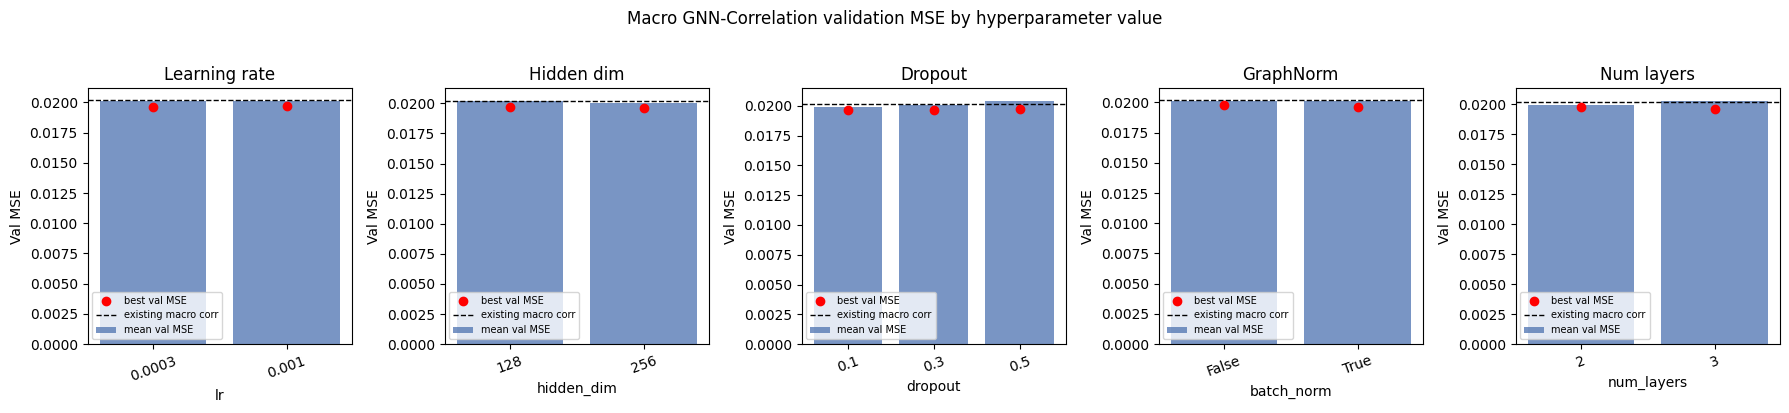

Saved: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\figures\gnn_corr_macro_hparam_search.png


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
params = [
    ('lr', 'Learning rate'),
    ('hidden_dim', 'Hidden dim'),
    ('dropout', 'Dropout'),
    ('batch_norm', 'GraphNorm'),
    ('num_layers', 'Num layers'),
]

baseline_line = None
baseline_macro_loss_path = Path(config.DATA_RESULTS_DIR) / 'gnn_corr_macro_val_loss.json'
if baseline_macro_loss_path.exists():
    with open(baseline_macro_loss_path) as fh:
        baseline_line = json.load(fh).get('best_val_loss')

for ax, (col, label) in zip(axes, params):
    group_mean = results_df.groupby(col)['val_mse'].mean()
    group_min = results_df.groupby(col)['val_mse'].min()
    x_vals = [str(v) for v in group_mean.index]
    ax.bar(x_vals, group_mean.values, color='#4C72B0', alpha=0.75, label='mean val MSE')
    ax.scatter(x_vals, group_min.values, color='red', zorder=5, label='best val MSE')
    if baseline_line is not None:
        ax.axhline(baseline_line, color='black', linestyle='--', linewidth=1, label='existing macro corr')
    ax.set_title(label)
    ax.set_xlabel(col)
    ax.set_ylabel('Val MSE')
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Macro GNN-Correlation validation MSE by hyperparameter value', y=1.02)
plt.tight_layout()
fig_path = Path(config.FIGURES_DIR) / 'gnn_corr_macro_hparam_search.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

In [11]:
# Quick checkpoint sanity check on a validation week.
best_ckpt = Path(config.CHECKPOINTS_DIR) / BEST_CHECKPOINT_NAME
assert best_ckpt.exists(), f'Best checkpoint not found: {best_ckpt}'

set_seeds()
best_model = GNNModelV2(
    in_channels=n_feats,
    hidden_dim=best_config['hidden_dim'],
    dropout=best_config['dropout'],
    num_layers=best_config['num_layers'],
    batch_norm=best_config['batch_norm'],
).to(device)
best_model.load_state_dict(torch.load(best_ckpt, map_location=device, weights_only=True))
best_model.eval()

val_weeks = splits.loc[splits['split'] == 'val', 'week'].sort_values().reset_index(drop=True)
sample_week = val_weeks.iloc[min(25, len(val_weeks) - 1)]
sample_pos = list(target.index).index(sample_week)
sample_ei = corr_graphs_train_val.get(sample_week, torch.zeros(2, 0, dtype=torch.long)).to(device)
x_sample = torch.tensor(features_3d[sample_pos], dtype=torch.float32).to(device)

with torch.no_grad():
    pred = best_model(x_sample, sample_ei)

print('Best model architecture:')
print(best_model)
print(f'Parameters: {sum(p.numel() for p in best_model.parameters()):,}')
print(f'Sanity check at {sample_week.date()}:')
print(f'  Output shape : {tuple(pred.shape)}')
print(f'  NaNs         : {pred.isnan().sum().item()}')
print(f'  min / max    : {pred.min().item():.4f} / {pred.max().item():.4f}')
print(f'Checkpoint    : {best_ckpt}')

Best model architecture:
GNNModelV2(
  (convs): ModuleList(
    (0): SAGEConv(19, 256, aggr=mean)
    (1-2): 2 x SAGEConv(256, 256, aggr=mean)
  )
  (bns): ModuleList(
    (0-2): 3 x GraphNorm(256)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)
Parameters: 275,201
Sanity check at 2023-06-26:
  Output shape : (465,)
  NaNs         : 0
  min / max    : 0.1393 / 0.4859
Checkpoint    : C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\checkpoints\gnn_corr_macro_hparam_best.pt


C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:350: UserWarning: GNNModelV2.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(
